# Day43_neural_network_grid_search
08-may-25

In [3]:
#!pip install tensorflow
!pip install keras

In [1]:
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'keras'

In [18]:
import pandas as pd

In [262]:
seed=7
np.random.seed(seed)

dataset=pd.read_csv('pima_indians_diabetes.csv')
dataset.head()


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [264]:
x=dataset.iloc[:,0:8]
y=dataset.iloc[:,8]

In [266]:
x.head()

,preg,plas,pres,skin,test,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [268]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: class, dtype: int64

In [270]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [272]:
dataset.shape

(768, 9)

In [274]:
dataset.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Create model

In [298]:
model=Sequential()
model.add(Dense(12,input_dim=8,activation='relu'))# it will add first hidden layer to the network with 12 neuron.  input_dim=8 as 8 input features, this will be mentioned only for 1 layer
model.add(Dense(8,activation='relu'))## it will add second hidden layer to the network with 8 neuron.
model.add(Dense(8,activation='relu'))## it will add third hidden layer to the network with 8 neuron.
model.add(Dense(1,activation='sigmoid'))# it will add 1 output layer to the network with 1 neuron.The last layer you add is always the output laye


C:\Users\Pandhari\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [306]:
# compile the model
model.compile(optimizer='adam',loss='BinaryCrossentropy',metrics=['accuracy'])
# loss='BinaryCrossentropy' - as we have binary class classification in output, if multiuclass classicatioon then we would ahve used "categoricalCrossentropy"


In [310]:
#fit the model
history=model.fit(x,y,validation_split=0.33,epochs=100,batch_size=10)
#validation_split=0.33- tsting data
#batch_size=10- means using minibatchsize gradiant descent

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6394 - loss: 28.7073 - val_accuracy: 0.6732 - val_loss: 13.2590
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6551 - loss: 11.1289 - val_accuracy: 0.6535 - val_loss: 5.7830
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5825 - loss: 5.1495 - val_accuracy: 0.5669 - val_loss: 1.3112
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5371 - loss: 0.7358 - val_accuracy: 0.6024 - val_loss: 0.7356
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5925 - loss: 0.6989 - val_accuracy: 0.6024 - val_loss: 0.7270
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6360 - loss: 0.6688 - val_accuracy: 0.5984 - val_loss: 0.7190
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6586 - loss: 0.6531 - val_accuracy: 0.6024 - val_loss: 0.7117
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6466 - loss: 0.6544 - val_accuracy: 0.6181 

In [312]:
scores=model.evaluate(x,y)
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6999 - loss: 0.5591
compile_metrics: 69.40%


In [316]:
type(history)

keras.src.callbacks.history.History

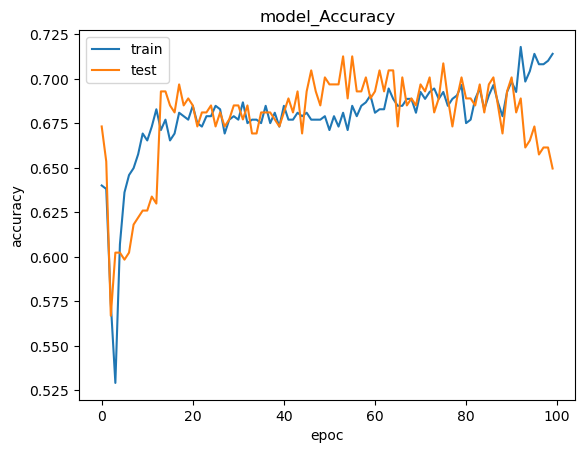

In [330]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model_Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoc')
plt.legend(['train','test'],loc='upper left')
plt.show()